In [2]:
import seaborn as sns 

In [3]:
import matplotlib.pyplot as plt 
import numpy as np

In [4]:
import pandas as pd

In [5]:

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("/Users/aashishmewada/Desktop/PRISM AI/PRISM_AI/data/raw/fraud_detection_dataset_5000.csv")

In [7]:
df.head()

,TransactionID,CustomerID,TransactionDate,TransactionTime,Age,Gender,Income,Location,AccountAgeDays,Membership,...,DistanceFromHome,CustomerTotalSpend,CustomerAverageSpend,CustomerComplaints,CustomerRating,CustomerHealthScore,RefundCount,ChargebackCount,SuspiciousActivityCount,Fraud
0,TXN100001,CUST2309,2025-02-27,00:51:00,65,Female,55611.48,"Chicago, IL",3021,Standard,...,26.3,18184.50,363.69,0,4.0,50,5,3,2,1
1,TXN100002,CUST1569,2025-03-21,07:20:00,66,Female,37776.28,"San Antonio, TX",401,Platinum,...,3.4,17551.31,358.19,1,4.5,78,2,3,2,0
2,TXN100003,CUST1727,2025-04-18,22:52:00,35,Non-Binary,142081.82,"Austin, TX",297,NaN,...,18.4,76926.08,392.48,2,1.3,70,1,3,3,1
3,TXN100004,CUST2316,2025-08-23,04:52:00,34,Male,55828.44,"Dallas, TX",2212,Platinum,...,70.1,5199.96,433.33,4,1.3,78,4,3,4,1
4,TXN100005,CUST1514,2026-05-13,18:53:00,73,Male,110035.43,"Los Angeles, CA",2797,NaN,...,4.0,49374.72,385.74,5,3.0,55,1,2,1,0


In [8]:
df.isnull().sum()

TransactionID                  0
CustomerID                     0
TransactionDate                0
TransactionTime                0
Age                            0
Gender                         0
Income                         0
Location                       0
AccountAgeDays                 0
Membership                  1091
ProductID                      0
Category                       0
Quantity                       0
Price                          0
TotalAmount                    0
PaymentMethod                  0
CardType                    3693
TransactionChannel             0
DeviceType                  2510
Browser                     2510
IPAddress                      0
PreviousTransactionCount       0
AverageTransactionAmount       0
TransactionFrequency           0
TimeSinceLastTransaction       0
FailedLoginAttempts            0
PasswordChangeCount            0
NewDeviceLogin                 0
IsInternational                0
DistanceFromHome               0
CustomerTo

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

TransactionID               0
CustomerID                  0
TransactionDate             0
TransactionTime             0
Age                         0
Gender                      0
Income                      0
Location                    0
AccountAgeDays              0
Membership                  0
ProductID                   0
Category                    0
Quantity                    0
Price                       0
TotalAmount                 0
PaymentMethod               0
CardType                    0
TransactionChannel          0
DeviceType                  0
Browser                     0
IPAddress                   0
PreviousTransactionCount    0
AverageTransactionAmount    0
TransactionFrequency        0
TimeSinceLastTransaction    0
FailedLoginAttempts         0
PasswordChangeCount         0
NewDeviceLogin              0
IsInternational             0
DistanceFromHome            0
CustomerTotalSpend          0
CustomerAverageSpend        0
CustomerComplaints          0
CustomerRa

In [11]:
df["Fraud"].value_counts()

Fraud
0    360
1    136
Name: count, dtype: int64

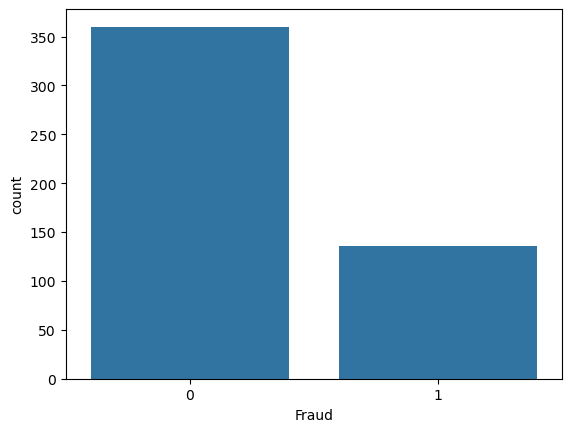

In [12]:
sns.countplot(
    x=df["Fraud"]
)

plt.show()

In [13]:
df.drop(
[
"TransactionID",
"CustomerID"
],
axis=1,
inplace=True
)

In [14]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"]
)

In [15]:
df["TransactionMonth"] = (
    df["TransactionDate"].dt.month
)


df["TransactionDay"] = (
    df["TransactionDate"].dt.day
)


df.drop(
"TransactionDate",
axis=1,
inplace=True
)

In [16]:
df["TransactionTime"] = pd.to_datetime(
    df["TransactionTime"]
)

In [17]:
df["TransactionHour"] = (
    df["TransactionTime"].dt.hour
)


df.drop(
"TransactionTime",
axis=1,
inplace=True
)

In [18]:
df.select_dtypes(
include="object"
).columns

Index(['Gender', 'Location', 'Membership', 'ProductID', 'Category',
       'PaymentMethod', 'CardType', 'TransactionChannel', 'DeviceType',
       'Browser', 'IPAddress'],
      dtype='object')

In [19]:
encoder = LabelEncoder()


for col in df.select_dtypes(
    include="object"
).columns:

    df[col] = encoder.fit_transform(
        df[col]
    )

In [20]:
df.head()

,Age,Gender,Income,Location,AccountAgeDays,Membership,ProductID,Category,Quantity,Price,...,CustomerComplaints,CustomerRating,CustomerHealthScore,RefundCount,ChargebackCount,SuspiciousActivityCount,Fraud,TransactionMonth,TransactionDay,TransactionHour
1,66,0,37776.28,12,401,1,368,4,5,324.78,...,1,4.5,78,2,3,2,0,3,21,7
8,23,1,45788.89,13,1976,0,378,0,1,205.92,...,0,1.2,91,4,1,0,0,3,5,0
19,19,1,105343.71,2,3555,3,77,3,3,461.13,...,5,1.3,35,0,1,1,0,10,16,22
24,29,0,26768.55,4,523,1,17,3,5,357.64,...,0,2.6,39,4,0,1,0,4,27,12
44,37,2,65547.86,14,2447,2,21,2,2,907.78,...,4,3.7,35,1,3,4,1,3,22,12


In [21]:
y = df["Fraud"]

In [22]:
X = df.drop(
"Fraud",
axis=1
)

In [23]:
X.shape, y.shape

((496, 37), (496,))

In [24]:
df.columns

Index(['Age', 'Gender', 'Income', 'Location', 'AccountAgeDays', 'Membership',
       'ProductID', 'Category', 'Quantity', 'Price', 'TotalAmount',
       'PaymentMethod', 'CardType', 'TransactionChannel', 'DeviceType',
       'Browser', 'IPAddress', 'PreviousTransactionCount',
       'AverageTransactionAmount', 'TransactionFrequency',
       'TimeSinceLastTransaction', 'FailedLoginAttempts',
       'PasswordChangeCount', 'NewDeviceLogin', 'IsInternational',
       'DistanceFromHome', 'CustomerTotalSpend', 'CustomerAverageSpend',
       'CustomerComplaints', 'CustomerRating', 'CustomerHealthScore',
       'RefundCount', 'ChargebackCount', 'SuspiciousActivityCount', 'Fraud',
       'TransactionMonth', 'TransactionDay', 'TransactionHour'],
      dtype='object')

In [25]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [26]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)

In [27]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [28]:
models = {

"Logistic Regression":
LogisticRegression(),

"Random Forest":
RandomForestClassifier(
    n_estimators=200
),

"Extra Trees":
ExtraTreesClassifier(
    n_estimators=200
),

"Gradient Boosting":
GradientBoostingClassifier(),

"XGBoost":
XGBClassifier(),

"LightGBM":
LGBMClassifier(),

"CatBoost":
CatBoostClassifier(
    verbose=0
)

}

In [29]:
results = []


for name,model in models.items():

    print(
        "Training:",
        name
    )

    model.fit(
        X_train_scaled,
        y_train
    )


    pred = model.predict(
        X_test_scaled
    )


    probability = model.predict_proba(
        X_test_scaled
    )[:,1]


    results.append({

        "Model":name,

        "Accuracy":
        accuracy_score(
            y_test,
            pred
        ),

        "Precision":
        precision_score(
            y_test,
            pred
        ),

        "Recall":
        recall_score(
            y_test,
            pred
        ),

        "F1 Score":
        f1_score(
            y_test,
            pred
        ),

        "ROC-AUC":
        roc_auc_score(
            y_test,
            probability
        )

    })

Training: Logistic Regression
Training: Random Forest
Training: Extra Trees
Training: Gradient Boosting
Training: XGBoost
Training: LightGBM
[LightGBM] [Info] Number of positive: 109, number of negative: 287
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.275253 -> initscore=-0.968134
[LightGBM] [Info] Start training from score -0.968134
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

In [30]:
results_df = pd.DataFrame(
    results
)


results_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Gradient Boosting,0.94,0.956522,0.814815,0.880000,0.968037
1,Random Forest,0.93,1.000000,0.740741,0.851064,0.964485
4,XGBoost,0.94,0.956522,0.814815,0.880000,0.963978
6,CatBoost,0.96,1.000000,0.851852,0.920000,0.963978
2,Extra Trees,0.91,1.000000,0.666667,0.800000,0.960934
5,LightGBM,0.96,1.000000,0.851852,0.920000,0.960426
0,Logistic Regression,0.83,0.656250,0.777778,0.711864,0.886859


In [31]:
import joblib
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [32]:
from catboost import CatBoostClassifier


fraud_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)


fraud_model.fit(
    X_train_scaled,
    y_train
)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.05, random_state=42, verbose=0)

In [33]:
joblib.dump(
    fraud_model,
    "models/fraud_model.pkl"
)


joblib.dump(
    scaler,
    "models/fraud_scaler.pkl"
)


joblib.dump(
    X.columns.tolist(),
    "models/fraud_features.pkl"
)

['models/fraud_features.pkl']

In [34]:
print(X_train.shape)
print(X_train.columns)

(396, 37)
Index(['Age', 'Gender', 'Income', 'Location', 'AccountAgeDays', 'Membership',
       'ProductID', 'Category', 'Quantity', 'Price', 'TotalAmount',
       'PaymentMethod', 'CardType', 'TransactionChannel', 'DeviceType',
       'Browser', 'IPAddress', 'PreviousTransactionCount',
       'AverageTransactionAmount', 'TransactionFrequency',
       'TimeSinceLastTransaction', 'FailedLoginAttempts',
       'PasswordChangeCount', 'NewDeviceLogin', 'IsInternational',
       'DistanceFromHome', 'CustomerTotalSpend', 'CustomerAverageSpend',
       'CustomerComplaints', 'CustomerRating', 'CustomerHealthScore',
       'RefundCount', 'ChargebackCount', 'SuspiciousActivityCount',
       'TransactionMonth', 'TransactionDay', 'TransactionHour'],
      dtype='object')
